In [12]:
from xrss.dataloader import XRayDataset, show_images_and_bboxes
from xrss.models import MetalMaskRandomForest

# Model Initialization and quality testing (not satisfactory)

In [13]:
yaml_file = "../xray_data/data.yaml"

train_dataset = XRayDataset(yaml_file, split="train")
val_dataset = XRayDataset(yaml_file, split="val")

In [14]:
model = MetalMaskRandomForest()

model.train(train_dataset)

Training on 4200 images.


Building Feature Set: 100%|██████████| 4200/4200 [00:11<00:00, 364.76it/s]


Training Complete.
Feature Importance (Aspect Ratio, Area, Solidity): [0.27807876 0.4057394  0.31618184]


Displaying sample images with ground truth bounding boxes:


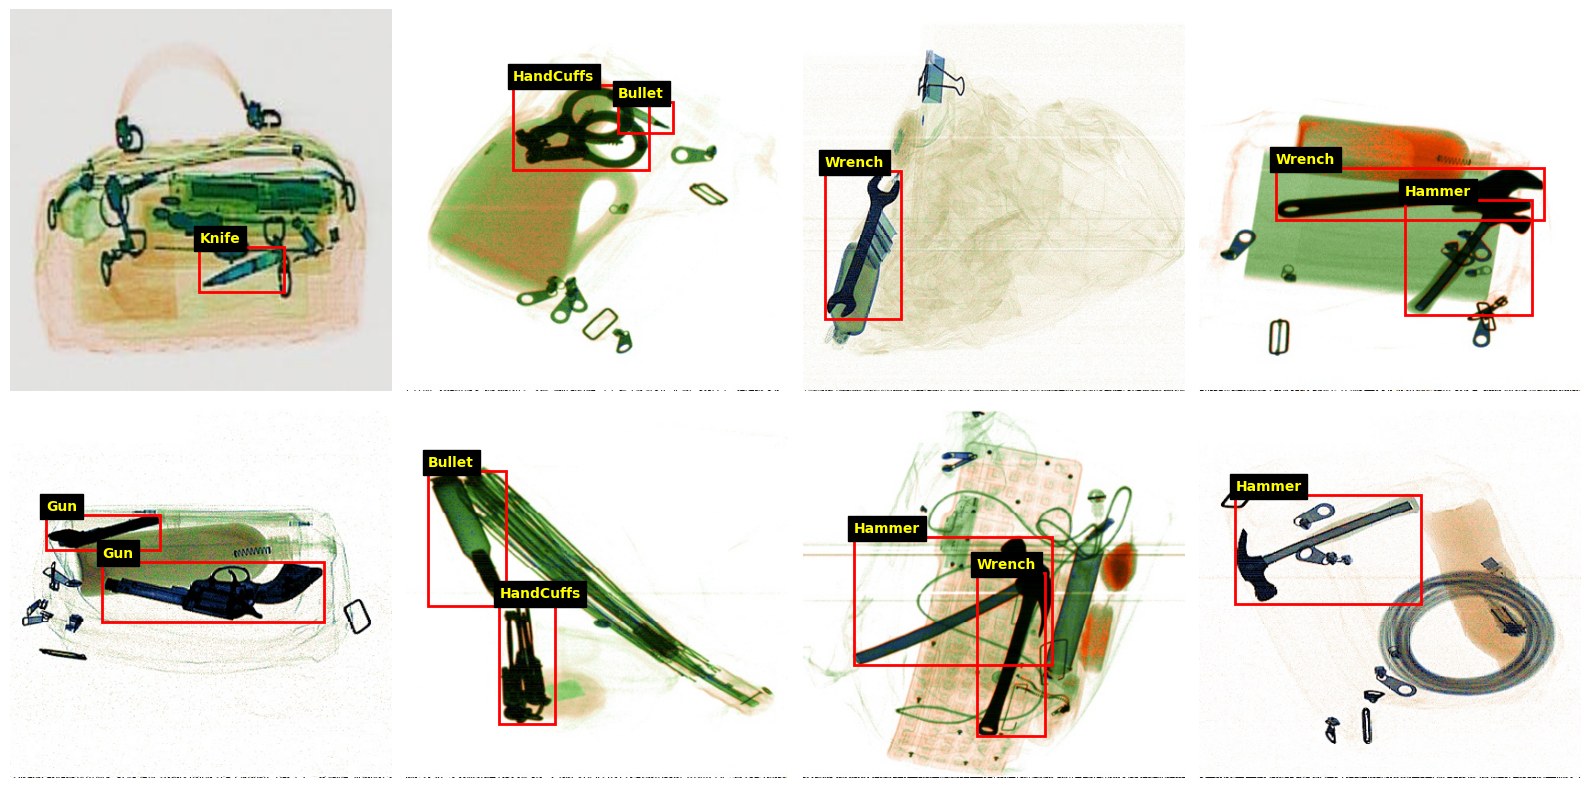

Displaying sample images with predicted bounding boxes:


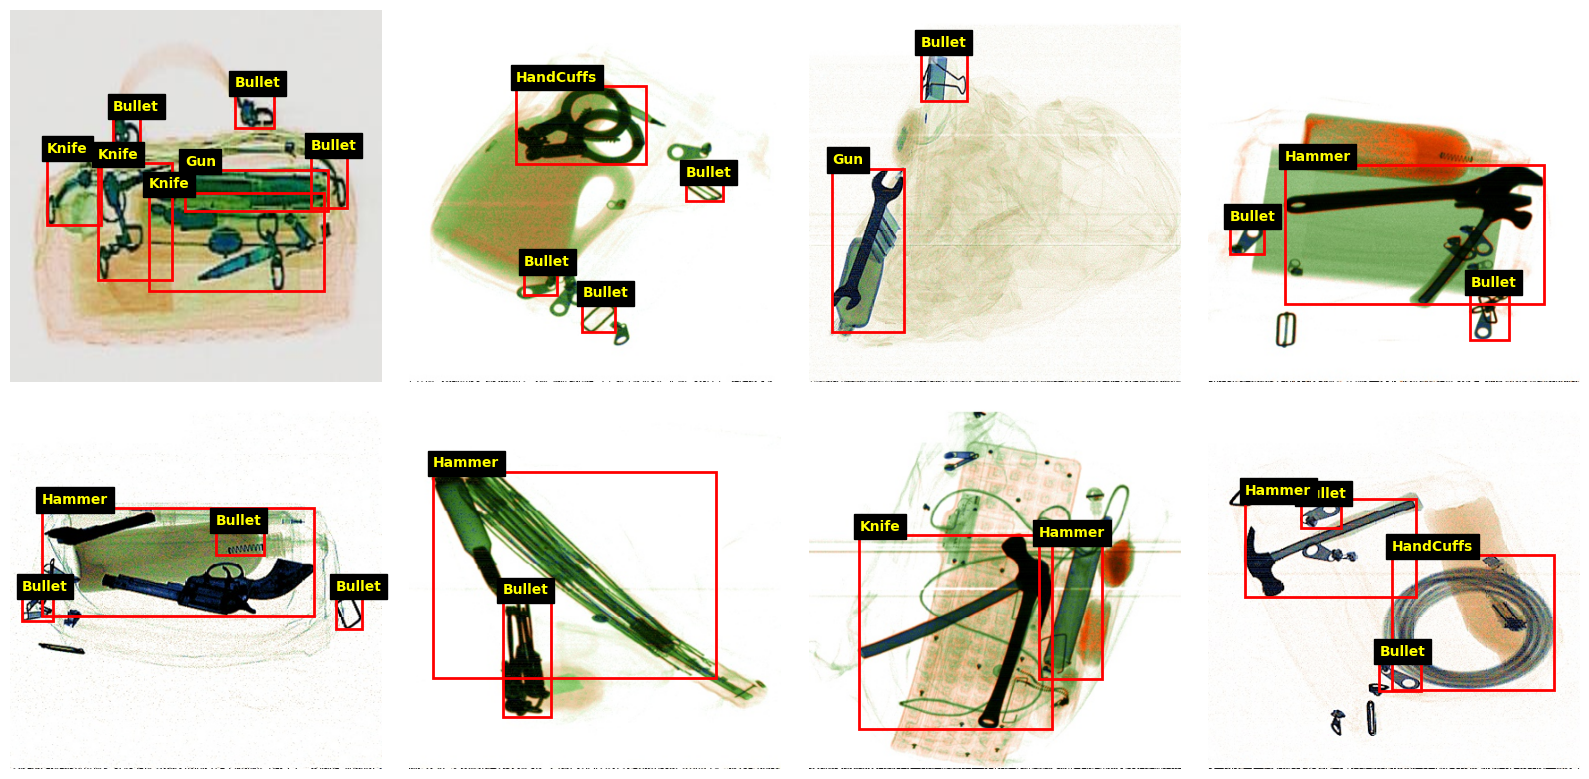

In [15]:
indexes = list(range(8))

images = [val_dataset[i][0] for i in indexes]
labels = [val_dataset[i][1] for i in indexes]

print("Displaying sample images with ground truth bounding boxes:")
show_images_and_bboxes(val_dataset, images, labels, cols=4)

preds = []
for img in images:
    boxes = model.detect(img)

    preds.append(boxes)

print("Displaying sample images with predicted bounding boxes:")
show_images_and_bboxes(val_dataset, images, preds, cols=4)